In [1]:
### Install pytorch

In [2]:
# pip install torch

In [3]:
import torch

### Tensors

In [4]:
# Number
t1 = torch.tensor([4.])
t1

tensor([4.])

In [5]:
t1.dtype

torch.float32

In [6]:
# Vector
t2 = torch.tensor([1., 2, 3, 4])
t2

tensor([1., 2., 3., 4.])

In [7]:
# Matrix
t3 = torch.tensor([
    [5., 6],
    [7, 8],
    [9, 10]
])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [8]:
# create a matrix  
#  Create 3 Dimessions array
t4 = torch.tensor([
    [
        [11, 12, 13],
        [14, 15, 16]
    ],
    [
        [17, 18, 19],
        [20, 21, 22]
    ]
])
t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [9]:
print(t1)
t1.shape


tensor([4.])


torch.Size([1])

In [10]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

### Tensor operation and Gradients

In [11]:
x = torch.tensor(3.)
w = torch.tensor(4., requires_grad = True)
b = torch.tensor(5., requires_grad = True)

x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [12]:
### Arithmetic Oprstions

y = w * x + b
y

tensor(17., grad_fn=<AddBackward0>)

In [13]:
# Compute derivates
y.backward()

In [14]:
# Display Grafients
print("dy/dx: ", x.grad)
print("dy/dx: ", w.grad)
print("dy/dx: ", b.grad)

dy/dx:  None
dy/dx:  tensor(3.)
dy/dx:  tensor(1.)


### Tensor Function


In [15]:
# Create a tensor with a fixed value for every element
t6 = torch.full((3,2), 42)
t6

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [16]:
## Concatinate two tensor with compatible shapes
t7 = torch.cat((t3, t6))
t7

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.],
        [42., 42.],
        [42., 42.],
        [42., 42.]])

In [17]:
# change the sin of each element
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165]])

In [18]:
# Change the shape of a tensor
t9 = t8.reshape(3, 2, 2)
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

In [19]:
### interoperability with Numpy
import numpy as np

x = np.array(([1,2], [3, 4.]))
x

array([[1., 2.],
       [3., 4.]])

In [20]:
y = torch.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [21]:
x.dtype, y.dtype

(dtype('float64'), torch.float64)

In [22]:
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

## Linear Regression from Scratch using pytorch
-  ***Logistic regression*** is used for binary classifiction problems, where the output is like 0/1 (yes/no, either/ or).
-  ***Linear Regression***  is used for multiclass classification problems, where the output has a multiple classes as answer.

In [23]:
import numpy as np
import torch

In [24]:

# Making traning data
# Input ---> (temp, rainfall, humidity) --> yield of apple and oranges crops

inputs = np.array([
    [73, 67, 43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70], 
                 
], dtype = 'float32')

In [25]:
## Targate (apple, oranges)
target = np.array([
    [56, 70],
    [81, 101],
    [119, 113],
    [22, 37],
    [103, 119]
], dtype = 'float32')

In [26]:
# Convert inputs and target to tensors
inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)


print(inputs)
print(target)

tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [27]:
### Weights and biases\

w = torch.randn(2, 3, requires_grad = True)
b = torch.randn(2, requires_grad = True)

print(w)
print(b)

tensor([[-0.9001,  1.4598,  0.7392],
        [ 0.5430, -2.1938,  0.4190]], requires_grad=True)
tensor([-1.3621,  0.5091], requires_grad=True)


In [28]:
### Define the model 
## z = x * w + b
def model(x):
    return x @ w.t() + b

In [29]:
# prediction
preds = model(inputs)
print(preds)

tensor([[  62.5229,  -88.8186],
        [  92.5000, -116.3149],
        [ 158.8148, -221.9150],
        [  -3.0491,  -22.9355],
        [ 128.4151, -143.2967]], grad_fn=<AddBackward0>)


In [30]:
## Loss funtions we will use is MSE -> Mean Squared Error
def MSE(y, y_hat):
    diff = y - y_hat

    return torch.sum(diff*diff)/diff.numel()

In [31]:
### Error
loss = MSE(target, preds)
print(loss)

tensor(26004.2402, grad_fn=<DivBackward0>)


In [32]:
### Compute gradients
loss.backward()

In [33]:
print(w)
print(w.grad)

tensor([[-0.9001,  1.4598,  0.7392],
        [ 0.5430, -2.1938,  0.4190]], requires_grad=True)
tensor([[   837.0388,   1629.3918,    835.5972],
        [-16943.7832, -20480.1758, -12148.1621]])


In [34]:
### Reset grad
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [35]:
### Adjust params

preds = model(inputs)
print(preds)

loss = MSE(target,  preds)
print(loss)

tensor([[  62.5229,  -88.8186],
        [  92.5000, -116.3149],
        [ 158.8148, -221.9150],
        [  -3.0491,  -22.9355],
        [ 128.4151, -143.2967]], grad_fn=<AddBackward0>)
tensor(26004.2402, grad_fn=<DivBackward0>)


In [36]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[   837.0388,   1629.3918,    835.5972],
        [-16943.7832, -20480.1758, -12148.1621]])
tensor([  11.6407, -206.6561])


In [37]:
## adjust weight & reset grad

learning_rate = 1e-5

with torch.no_grad():
    w -= w.grad * learning_rate
    b -= b.grad * learning_rate

    w.grad.zero_()
    b.grad.zero_()

In [38]:
print(w)
print(b)

tensor([[-0.9084,  1.4435,  0.7308],
        [ 0.7124, -1.9890,  0.5405]], requires_grad=True)
tensor([-1.3622,  0.5112], requires_grad=True)


In [39]:
### Calculate again

preds  = model(inputs)
loss = MSE(preds, target)
print(loss)

tensor(18188.3867, grad_fn=<DivBackward0>)


In [40]:
## Traning for multiple epochs
for i in range(400):
    preds = model(inputs)
    loss = MSE(target, preds)
    loss.backward()
    with torch.no_grad():
        w -= w.grad * learning_rate
        b -= b.grad * learning_rate

        w.grad.zero_()
        b.grad.zero_()
print(f"Epochs({i}/{100}) & Loss {loss}")

Epochs(399/100) & Loss 15.440145492553711


In [41]:
from math import sqrt
sqrt(loss)

C:\Users\angaj\AppData\Local\Temp\ipykernel_10128\3167310485.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  sqrt(loss)


3.929395054274094

In [42]:
preds

tensor([[ 56.4877,  68.8145],
        [ 81.6477, 100.8984],
        [121.0497, 110.0940],
        [ 18.4555,  47.6032],
        [102.2120, 115.2489]], grad_fn=<AddBackward0>)

In [43]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

In [44]:
## Fashion MNIST Neural Net example using Pytorch

In [45]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


In [48]:
## Download training data from open datatsets
traning_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = ToTensor(),
)

## Downlaod Test data from open datasets

test_data = datasets.FashionMNIST(
    root = "data",
    train=False,
    download = True,
    transform = ToTensor()
)

100%|██████████| 26.4M/26.4M [00:04<00:00, 5.87MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 165kB/s]
100%|██████████| 4.42M/4.42M [00:03<00:00, 1.11MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.45MB/s]


In [50]:
batch_size = 64

# Create data loaders
train_dataloader = DataLoader(traning_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for x, y in test_dataloader:
    print("Shape of x [N, C, H, W] ", x.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of x [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [64]:
## Get CPU and GPU device for traning
device = "cuda" if torch.cuda.is_available() else "cpu"

model = NeuralNetwork().to(device)

print(device)

cpu


In [65]:
## Define the Neural Network Model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super(NeuralNetwork, self).__init__()
        
        self.flatten = nn.Flatten()

         # Hiden layes with Relu activation function
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)  
    )

    def forward(self, x):
       x = self.flatten(x)
       logits = self.linear_relu_stack(x)
       return logits


model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [77]:
## Cross Entropy Loss -----> Because it is a multiclass classification problem
loss_fn = nn.CrossEntropyLoss()

## Optimizer ---> SGD ---> Stochastic Gradient Descent
## lr = leaning Rate
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3)

In [90]:
# model Traning 
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()

    for batch, (x, y) in enumerate(dataloader):
        x, y = x.to(device), y.to(device) # realated to gpu computation

     ## Compute prediction error
        pred = model(x)
        loss = loss_fn(pred, y)

        ## Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


        if batch %100 == 0:
            loss, current = loss.item(), batch * len(x)
            print(f"loss: {loss} [{current}/{size}] ")
        

In [93]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)

    num_batches = len(dataloader)

    model.eval()
    test_loss, correct = 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches # AVG loss per batch
    correct /= size # Age of correct prediciton or accuracy

    print(f"Test Error: \n Accuracy: {100+correct} %, Avg loss {test_loss}\n")

In [94]:
epochs = 5
for  t in range(epochs):
    print(f"Epoc {t+1} \n---------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)

print("Done\n")

Epoc 1 
---------------------
loss: 1.0648564100265503 [0/60000] 
loss: 1.0767951011657715 [6400/60000] 
loss: 0.880462646484375 [12800/60000] 
loss: 1.037667155265808 [19200/60000] 
loss: 0.9012781977653503 [25600/60000] 
loss: 0.9499200582504272 [32000/60000] 
loss: 0.9878349304199219 [38400/60000] 
loss: 0.9431886672973633 [44800/60000] 
loss: 0.9616288542747498 [51200/60000] 
loss: 0.9184931516647339 [57600/60000] 
Test Error: 
 Accuracy: 100.6644 %, Avg loss 0.9221959425385591

Epoc 2 
---------------------
loss: 0.9796370267868042 [0/60000] 
loss: 1.0089622735977173 [6400/60000] 
loss: 0.798621416091919 [12800/60000] 
loss: 0.9727969765663147 [19200/60000] 
loss: 0.8400273323059082 [25600/60000] 
loss: 0.8808173537254333 [32000/60000] 
loss: 0.9326874017715454 [38400/60000] 
loss: 0.8931484222412109 [44800/60000] 
loss: 0.903209388256073 [51200/60000] 
loss: 0.8703118562698364 [57600/60000] 
Test Error: 
 Accuracy: 100.6794 %, Avg loss 0.8696605680854457

Epoc 3 
----------------

In [95]:
## Save model
torch.save(model.state_dict(), "model.pth")
print("Saved model state to model.pth")

Saved model state to model.pth


In [103]:
### prediction
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "shirt",
    "sneaker",
    "bag",
    "Angaj boot"
]

model.eval()
x,y = test_data[0][0], test_data[0][1]
x = x.to(device)

with torch.no_grad():
    pred  = model(x)
    predicted, actual = classes[pred[0].argmax(0)], classes[y]
    print(f"Predicted: {predicted} Actual: {actual}")

Predicted: Angaj boot Actual: Angaj boot


<function matplotlib.pyplot.show(close=None, block=None)>

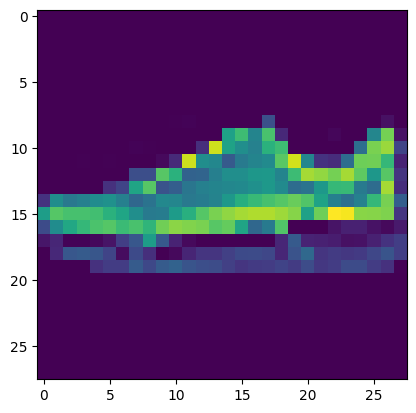

In [102]:
import matplotlib.pyplot as plt
plt.imshow(x.cpu().squeeze())
plt.show